In [152]:
import re
import shutil

import nibabel as nib
import numpy as np
import colorcet as cc
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from time import time
from PIL import Image

In [119]:
# Reportlab params for reports

MontSerratBold = pdfmetrics.EmbeddedType1Face('../../../utils/fonts/montserrat/Montserrat-Bold.afm', '../../../utils/fonts/montserrat/Montserrat-Bold.pfb')
MontSerratLight = pdfmetrics.EmbeddedType1Face('../../../utils/fonts/montserrat/Montserrat-Light.afm', '../../../utils/fonts/montserrat/Montserrat-Light.pfb')

# Montserrat Bold

pdfmetrics.registerTypeFace(MontSerratBold)
montserrat_bold_name = 'Montserrat-Bold'

montserrat_bold_font = pdfmetrics.Font('Montserrat-Bold',
                           montserrat_bold_name,
                           'WinAnsiEncoding')

pdfmetrics.registerFont(montserrat_bold_font)

# Montserrat Light

pdfmetrics.registerTypeFace(MontSerratLight)
montserrat_light_name = 'Montserrat-Light'

montserrat_light_font = pdfmetrics.Font('Montserrat-Light',
                           montserrat_light_name,
                           'WinAnsiEncoding')

pdfmetrics.registerFont(montserrat_light_font)

# Helper function 

In [87]:
def standardize(signals):
    
    signals_out = []
    for x in signals.T:
        
        signals_out.append((x-np.nanmean(x))/np.nanstd(x))
    
    return np.array(signals_out).T

def clean_clustimg(cluster_img, clust_size = 9):

    output_img = np.zeros(cluster_img.shape)
    
    for i in np.unique(cluster_img[cluster_img!=0]):

        label_img, nb_cluster = label(cluster_img == i)
        
        for j in range(1,nb_cluster):

            if (label_img == j).sum() > clust_size:
            
                output_img[label_img == j] = i

    return output_img

# Parameters

In [90]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/rawdata/')

root_3D_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/')
root_3D_dir = sorted([x for x in root_3D_path.rglob('*') if x.is_file() and re.match(f'^.*acq-3Dscan.*.nii.gz$', x.name)])

print(f'We found {len(root_3D_dir)} files')

save_dir_QC = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/77_QCs/00_individual_checks/')
save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/')

t_r = 2.4

We found 50 files


# QC slices

In [92]:
for file_name in tqdm(root_3D_dir):

    img = nib.load(file_name)
    
    prefix = file_name.name.split('acq')[0]
    
    file_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^{prefix}.*pose.*.nii.gz$', x.name)])
    
    correlation_curves = []
    local_inds = []
    
    for slice_name in file_dir:
    
        slice_img = nib.load(slice_name)
        slice_data = slice_img.get_fdata().mean(-1).squeeze().flatten()
        
        correlation_curve = []
        
        for slice in range(img.shape[0]):
        
            correlation_curve.append(np.corrcoef(img.get_fdata()[slice,:,:].flatten(), slice_data)[0,1])
    
        # Identifies slice
        
        ind = np.argmax(correlation_curve)
        local_inds.append(ind)
        
        slice_mask = np.zeros(img.shape)
        slice_mask[ind,:,:] = 1
        
        # output slice mask
        
        save_name = save_dir / file_name.parent.parent.name / file_name.parent.name / (slice_name.name.split('pwd')[0] + 'sliceMask.nii.gz')
        save_name.parent.mkdir(exist_ok = True, parents = True)
        
        nib.save(
            nib.Nifti1Image(
                slice_mask,
                affine = img.affine
            ),
            save_name
        )
        
        # Display slices
        
        fig, ax = plt.subplots(1,2,dpi = 200, figsize = (12,5), facecolor = 'k')
        
        img_2_display = np.log10(img.get_fdata()[ind,:,:])
        img_2_display[np.isinf(img_2_display)] = 0
        img_2_display[np.isnan(img_2_display)] = 0
        
        ax[0].imshow(img_2_display, cmap = 'Greys_r', vmin = 0.7, vmax = 2.2)
        ax[0].axis('off')
        
        img_2_display = np.log10(slice_img.get_fdata().mean(-1).squeeze())
        img_2_display[np.isinf(img_2_display)] = 0
        img_2_display[np.isnan(img_2_display)] = 0
        
        ax[1].imshow(img_2_display, cmap = 'Greys_r', vmin = 0.7, vmax = 2.2)
        ax[1].axis('off')
        
        plt.tight_layout()
        
        save_name = save_dir_QC / file_name.parent.parent.name / file_name.parent.name / (slice_name.name.split('pwd')[0] + 'sliceComparison.png')
        save_name.parent.mkdir(exist_ok = True, parents = True)
        
        plt.savefig(save_name)
        plt.close('all')
    
        # saves slice QC
        
        correlation_curves.append(np.array(correlation_curve))
    
    # Display slice_QC
    
    fig, ax = plt.subplots(1,1,dpi = 200, facecolor = 'k')
    ax.set(facecolor = 'k')
    
    xm = np.min(correlation_curves)
    
    for i,correlation_curve in enumerate(correlation_curves):
    
        plt.plot(correlation_curve, label = f'pose-{i}')
        
        plt.axvline(local_inds[i], c = 'w', ls = ':')
    
        plt.annotate(local_inds[i], (local_inds[i]-1,xm+0.05), color = 'w', horizontalalignment = 'right')
    
    for spine in ax.spines:
    
        ax.spines[spine].set_color('w')
    
    ax.set_xlabel('Slice #', c = 'w')
    ax.set_ylabel('Correlation (r)', c = 'w')
    
    plt.tight_layout()
    
    plt.legend()
    
    save_name = save_dir_QC / file_name.parent.parent.name / file_name.parent.name / (file_name.name.split('pwd')[0] + 'sliceIDs.png')
    save_name.parent.mkdir(exist_ok = True, parents = True)
    
    plt.savefig(save_name)
    plt.close('all')

  0%|                                                                                                                 | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_2922259/2986695154.py:48: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(img.get_fdata()[ind,:,:])
/tmp/ipykernel_2922259/2986695154.py:55: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(slice_img.get_fdata().mean(-1).squeeze())
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [05:06<00:00,  6.13s/it]


# QC angio

In [145]:
nb_col = 6
x_offset = 15
y_offset = 15

for file_name in tqdm(root_3D_dir):
    
    img = nib.load(file_name)
    
    [X,Y,Z] = img.shape
    [x,y,z] = img.header.get_zooms()
        
    # display coronal
    
    slice_ids = np.linspace(5, X-5,nb_col).astype(int)
    
    fig, ax = plt.subplots(1, nb_col, figsize = (10, 1.5*Y*y/(Z*z)*10/nb_col), dpi = 200, facecolor = 'k')
    
    for i in range(nb_col):
    
        img_2_display = np.log10(img.get_fdata()[slice_ids[i],:,:])
        img_2_display[np.isinf(img_2_display)] = 0
        img_2_display[np.isnan(img_2_display)] = 0
        ax[i].imshow(img_2_display, cmap = 'Greys_r', aspect = y/z, vmin = 0.6, vmax = 2.2)
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        
        for spine in ax[i].spines:
    
            ax[i].spines[spine].set_color('w')
    
    plt.tight_layout()
    
    save_name = save_dir_QC / file_name.parent.parent.name / file_name.parent.name / (file_name.name.split('pwd')[0] + 'coronal.png')
    plt.savefig(save_name)
    plt.close('all')
    
    # display sagittal
    
    slice_ids = np.linspace(x_offset, Z//2,nb_col).astype(int)
    
    fig, ax = plt.subplots(1, nb_col, figsize = (10, 1.5*X*x/(Y*y)*10/nb_col), dpi = 200, facecolor = 'k')
    
    for i in range(nb_col):
    
        img_2_display = np.rot90(np.log10(img.get_fdata()[:,:,slice_ids[i]]), 3)
        img_2_display[np.isinf(img_2_display)] = 0
        img_2_display[np.isnan(img_2_display)] = 0
        ax[i].imshow(img_2_display, cmap = 'Greys_r', aspect = y/z, vmin = 0.6, vmax = 2.2)
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        
        for spine in ax[i].spines:
    
            ax[i].spines[spine].set_color('w')
    
    plt.tight_layout()

    save_name = save_dir_QC / file_name.parent.parent.name / file_name.parent.name / (file_name.name.split('pwd')[0] + 'sagittal.png')
    plt.savefig(save_name)
    plt.close('all')

    # display horizontal
    
    slice_ids = np.linspace(y_offset, Y-y_offset,nb_col).astype(int)
    
    fig, ax = plt.subplots(1, nb_col, figsize = (10, 1.5*X*x/(Z*z)*10/nb_col), dpi = 200, facecolor = 'k')
    
    for i in range(nb_col):
    
        img_2_display = np.rot90(np.log10(img.get_fdata()[:,slice_ids[i],:]), 2)
        img_2_display[np.isinf(img_2_display)] = 0
        img_2_display[np.isnan(img_2_display)] = 0
        ax[i].imshow(img_2_display, cmap = 'Greys_r', aspect = y/z, vmin = 0.6, vmax = 2.2)
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        
        for spine in ax[i].spines:
    
            ax[i].spines[spine].set_color('w')
    
    plt.tight_layout()

    save_name = save_dir_QC / file_name.parent.parent.name / file_name.parent.name / (file_name.name.split('pwd')[0] + 'horizontal.png')
    plt.savefig(save_name)
    plt.close('all')

  0%|                                         | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_2922259/3478654684.py:20: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(img.get_fdata()[slice_ids[i],:,:])
/tmp/ipykernel_2922259/3478654684.py:70: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.rot90(np.log10(img.get_fdata()[:,slice_ids[i],:]), 2)
100%|████████████████████████████████| 50/50 [00:50<00:00,  1.01s/it]


# QC functional

In [84]:
for i, file_name in enumerate(root_3D_dir):

    print(f'{i} - {file_name.name}')

0 - sub-cp230328a_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz
1 - sub-cp230328b_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz
2 - sub-cp230329a_ses-1MEDISOses1_acq-3Dscan_probe-linear_pwd.nii.gz
3 - sub-cp230329b_ses-1CPTses2_acq-3Dscan_probe-linear_pwd.nii.gz
4 - sub-cp230330a_ses-1CPTses3_acq-3Dscan_probe-linear_pwd.nii.gz
5 - sub-cp230331a_ses-1CPTses4_acq-3Dscan_probe-linear_pwd.nii.gz
6 - sub-cp230331b_ses-1CPTses4_acq-3Dscan_probe-linear_pwd.nii.gz
7 - sub-cp230405a_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
8 - sub-cp230405b_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
9 - sub-cp230405c_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
10 - sub-cp230406a_ses-1HALOses1_acq-3Dscan_probe-linear_pwd.nii.gz
11 - sub-cp230406b_ses-1HALOses1_acq-3Dscan_probe-linear_pwd.nii.gz
12 - sub-cp230412a_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
13 - sub-cp230412b_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
14 - sub-cp230412c_ses-1CPTses5_acq-3Dscan_probe-linear_pw

In [94]:
for file_name in tqdm(root_3D_dir[47:]):

    prefix = file_name.name.split('acq')[0]
    
    file_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^{prefix}.*pose.*.nii.gz$', x.name)])
    
    print(prefix)
    
    correlation_curves = []
    local_inds = []
    
    for slice_name in file_dir:

        ###################### Loading data
        
        # loads the data
        
        img = nib.load(slice_name)

        template_img = np.log10(img.get_fdata().mean(-1)).squeeze()
        template_img[np.isinf(template_img)] = 0
        template_img[np.isnan(template_img)] = 0
        
        [X,Y,Z,T] = img.shape
        
        mask_img = math_img('a.mean(-1)>0', a = img)

        # into casoratti
        
        signals = apply_mask(img, mask_img)
        signals_norm = standardize(signals)

        ###################### Display raw carpet

        fig,ax = plt.subplots(1,1, figsize = (10,5),dpi = 200, facecolor = 'k')
        
        ax.imshow(signals_norm.T, cmap = 'Greys_r', aspect = 'auto', vmin = -3, vmax = 3)
        fig.suptitle('Raw', c = 'w', fontsize = 25)
        
        ax.axis('off')
        
        plt.tight_layout()
        
        save_name = save_dir_QC / file_name.parent.parent.name / file_name.parent.name / (slice_name.name.split('pwd')[0] + 'rawCarpet.png')
        save_name.parent.mkdir(exist_ok = True, parents = True)
        
        plt.savefig(save_name)
        plt.close('all')

        ###################### Display detrended

        # detrends
        
        signals_clean = clean(
            signals,
            t_r = t_r,
            highpass = 0.01
        )

        # Displays carpet
        
        fig,ax = plt.subplots(1,1, figsize = (10,5),dpi = 200, facecolor = 'k')
        
        ax.imshow(signals_clean.T, cmap = 'Greys_r', aspect = 'auto', vmin = -3, vmax = 3)
        fig.suptitle('Detrended', c = 'w', fontsize = 25)
        
        ax.axis('off')
        
        plt.tight_layout()
        
        save_name = save_dir_QC / file_name.parent.parent.name / file_name.parent.name / (slice_name.name.split('pwd')[0] + 'detrendedCarpet.png')
        save_name.parent.mkdir(exist_ok = True, parents = True)
        
        plt.savefig(save_name)
        plt.close('all')

        ###################### Display GS

        fig, ax = plt.subplots(1,1,figsize = (10,5), dpi = 200, facecolor = 'k')
        
        ax.set(facecolor = 'k')
        
        ax.plot(np.arange(T)*t_r, signals_norm.mean(-1), lw = 0.5, zorder = 5, label = 'raw')
        ax.plot(np.arange(T)*t_r, signals_clean.mean(-1), lw = 0.5, zorder = 5, label = 'detrended')
        
        [ax.spines[spine].set_color('w') for spine in ax.spines]
        
        ax.axhline(0, ls = '--',  c= 'w', zorder = 0)
        ax.axhline(2, ls = ':',  c= 'w', zorder = 0)
        
        ax.set_yticks([0,2], [0,2], c = 'w')
        
        x_ticks = np.linspace(0,300*(T*t_r//300),4).astype(int)
        ax.set_xticks(x_ticks, x_ticks, c = 'w')
        
        ax.set_xlabel('Time (s)', c = 'w')
        ax.set_ylabel('Normalised PD ($\sigma$)', c = 'w')
        
        plt.xlim(0, T*t_r)
        
        plt.legend()
        
        plt.suptitle('GS', c = 'w', fontsize = 25)
        
        plt.tight_layout()
        
        save_name = save_dir_QC / file_name.parent.parent.name / file_name.parent.name / (slice_name.name.split('pwd')[0] + 'GSTS.png')
        save_name.parent.mkdir(exist_ok = True, parents = True)
        
        plt.savefig(save_name)
        plt.close('all')

        ###################### Display spatial correlation

        fig, ax = plt.subplots(1,1,figsize = (10,5), dpi = 200, facecolor = 'k')
        
        ax.set(facecolor = 'k')
        
        for window, window_label in zip([np.arange(25).astype(int), ((T/2)+np.arange(25)).astype(int), np.flip(T-np.arange(25)-1).astype(int)], ['Start', 'Middle', 'End']):
        
            ref_img = signals[window,:].mean(0)
            
            spatial_corr = np.array([np.corrcoef(ref_img, x)[0,1] for x in signals])
            
            ax.plot(np.arange(T)*t_r, spatial_corr, lw = 0.5, zorder = 5, label = window_label)
            
        [ax.spines[spine].set_color('w') for spine in ax.spines]
        
        ax.axhline(0, ls = '--',  c= 'w', zorder = 0)
        
        ax.set_yticks([0, 0.5 ,1], [0, 0.5,1], c = 'w')
        ax.set_ylim(0,1)
        
        x_ticks = np.linspace(0,300*(T*t_r//300),4).astype(int)
        ax.set_xticks(x_ticks, x_ticks, c = 'w')
        
        ax.set_xlabel('Time (s)', c = 'w')
        ax.set_ylabel('r', c = 'w')
        
        plt.xlim(0, T*t_r)
        
        plt.legend()
        
        plt.suptitle('spatial autocorrelation', c = 'w', fontsize = 25)
        
        plt.tight_layout()
        
        save_name = save_dir_QC / file_name.parent.parent.name / file_name.parent.name / (slice_name.name.split('pwd')[0] + 'spatialCorrelation.png')
        save_name.parent.mkdir(exist_ok = True, parents = True)
        
        plt.savefig(save_name)
        plt.close('all')

        ###################### Display tSNR and GS correlation

        tSNR_vect = signals.mean(0)/signals_clean.std(0)
        tSNR = unmask(tSNR_vect, mask_img)
        
        GS = signals_clean.mean(1)
        GS_cor = [np.corrcoef(GS, x)[0,1] for x in signals_clean.T]

        # displays the maps

        fig = plt.figure(figsize = (10,5), dpi = 200, facecolor = 'k')
        subfigs = fig.subfigures(2,1,height_ratios=[9,1])
        
        ax = subfigs[0].subplots(1,2)
        
        
        ax[0].imshow(tSNR.get_fdata().squeeze(), cmap = cc.cm['fire'])
        ax[0].axis('off')
        ax[0].set_title('tSNR', c = 'w', fontsize = 25)
        
        img_2_display = unmask(GS_cor, mask_img).get_fdata().squeeze()
        alpha = (img_2_display != 0).astype('float')
        ax[1].imshow(img_2_display, cmap = cc.cm['CET_D1'], vmin = -0.5, vmax = 0.5, alpha = alpha)
        ax[1].axis('off')
        ax[1].set_title('GS correlation', c = 'w', fontsize = 25)
        
        ax = subfigs[1].subplots(1,2)
        
        v = np.linspace(tSNR_vect.min(), tSNR_vect.max(),256)
        ax[0].imshow(v[:,None].T, aspect = 'auto', cmap = cc.cm['fire'], vmin = tSNR_vect.min(), vmax = tSNR_vect.max())
        xticks = tSNR_vect.min(), tSNR_vect.max()
        xticks_labels = [int(x) for x in xticks]
        ax[0].set_xticks([0.5, 255.5], xticks_labels, c = 'w')
        
        v = np.linspace(-0.5, 0.5,256)
        ax[1].imshow(v[:,None].T, aspect = 'auto', cmap = cc.cm['CET_D1'], vmin = -0.5, vmax = 0.5)
        ax[1].set_xticks([0.5, 123.5, 255.5], [-0.5,0,0.5], c = 'w')
        
        plt.tight_layout()
        
        save_name = save_dir_QC / file_name.parent.parent.name / file_name.parent.name / (slice_name.name.split('pwd')[0] + 'QCmaps.png')
        save_name.parent.mkdir(exist_ok = True, parents = True)
        
        plt.savefig(save_name)
        plt.close('all')

        ###################### PCA

        [u,s,v] = np.linalg.svd(signals_clean.T)

        # Scree

        fig, ax = plt.subplots(1,1,dpi = 200, facecolor = 'k')
        ax.set(facecolor = 'k')
        
        plt.plot(np.arange(len(s)), 100*s**2/((s**2).sum()), c = 'w', ls = ':')
        plt.scatter(np.arange(len(s)), 100*s**2/((s**2).sum()), c = 'w')
        
        plt.xlim(-0.5, 19.5)
        
        ax.spines['bottom'].set_color('w')
        ax.spines['left'].set_color('w')
        
        y_ticks = np.round(np.linspace(0, 100*(5*(s[0]**2/((s**2).sum())*100)//5)/100,4),2)
        y_ticks_labels = [str(x).ljust(4, '0') for x in y_ticks]
        ax.set_yticks(y_ticks, y_ticks_labels, c = 'w')
        
        ax.set_ylabel('VE (%)', c = 'w')
        ax.set_xlabel('SV #', c = 'w')
        
        plt.suptitle('Scree', c = 'w', fontsize = 25)
        
        plt.tight_layout()
        
        save_name = save_dir_QC / file_name.parent.parent.name / file_name.parent.name / (slice_name.name.split('pwd')[0] + 'scree.png')
        save_name.parent.mkdir(exist_ok = True, parents = True)
        
        plt.savefig(save_name)
        plt.close('all')

        # PCs

        nb_modes = 10
        
        for i in range(nb_modes):
        
            factor = np.sign(2*(u[:,i]>0).sum()/len(u[:,i])-1)
            
            fig = plt.figure(figsize = (10,10), dpi = 200, facecolor = 'k')
            subfigs = fig.subfigures(2,1)
        
            ################### TS
            
            ax = subfigs[1].subplots(1,1)
            ax.set(facecolor = (0,0,0,0))
            ax.plot(np.arange(T)*t_r, factor*v[i,:], c = 'C1')
        
            ax.spines['bottom'].set_color('w')
            ax.spines['left'].set_color('w')
            ax.spines['top'].set_color((0,0,0,0))
            ax.spines['right'].set_color((0,0,0,0))
        
            x_ticks = np.linspace(0,300*(T*t_r//300),4).astype(int)
            ax.set_xticks(x_ticks, x_ticks, c = 'w')
            
            ax.set_xlabel('Time (s)', c = 'w')
            ax.set_ylabel('PD (arb.u.)', c = 'w')
        
            ################### map
            
            ax = subfigs[0].subplots(1,2)
        
            ax[0].imshow(template_img, aspect = 0.1/0.11, cmap = 'Greys_r', vmin = 0.6, vmax = 2.2)    
            img_2_display = unmask(u[:,i], mask_img).get_fdata().squeeze()
            cm = abs(img_2_display).max()
            mask = ((img_2_display != 0)*(abs(img_2_display)/cm)).astype(float)
            ax[0].imshow(factor*img_2_display, aspect = 0.1/0.11, cmap = cc.cm['CET_D1'], vmin = -cm, vmax = cm, alpha = mask)
            ax[0].axis('off')
        
            ax[0].set_title(f'PC:{i}', c = 'w', fontsize = 25)
        
            ################### Power Spectrum
            
            freq, Pws = welch(v[i,:], fs = 1/t_r)
        
            ax[1].set(facecolor = 'k')
            ax[1].plot(freq, Pws, c = 'C1')
        
            ax[1].spines['bottom'].set_color('w')
            ax[1].spines['left'].set_color('w')
            
            ax[1].set_yticks([])
            
            ax[1].set_ylabel('Power density (arb.u.)', c = 'w')
            x_ticks = np.round(np.linspace(0, freq.max(),4),2)
            x_ticks_labels = [str(x).ljust(4,'0') for x in x_ticks]
            ax[1].set_xlim(0,freq.max())
            ax[1].set_xticks(x_ticks, x_ticks_labels, c = 'w')
            ax[1].set_xlabel('f (Hz)', c = 'w')
            
            ax[1].set_title('Power Spectrum', c = 'w', fontsize = 25)
        
            plt.tight_layout()
        
            save_name = save_dir_QC / file_name.parent.parent.name / file_name.parent.name / (slice_name.name.split('pwd')[0] + f'PC{i}.png')
            save_name.parent.mkdir(exist_ok = True, parents = True)
            
            plt.savefig(save_name)
            plt.close('all')

        ###################### ICA

        # ICs

        # Computes ICA for a bunch of k clusters
        
        n_components = 10
        
        # fit the ICA
        
        ica = FastICA(n_components=n_components)
        _ = ica.fit(signals_clean.T)
        
        # extract spatial and temporal components
        
        components = ica.components_
        sources = ica.transform(signals_clean.T)
        reconstruction = np.dot(sources, ica.mixing_.T).T
        
        nb_modes = 10

        for i in range(nb_modes)[1:]:
        
            factor = np.sign(2*(sources[:,i]>0).sum()/len(sources[:,i])-1)
            
            fig = plt.figure(figsize = (10,10), dpi = 200, facecolor = 'k')
            subfigs = fig.subfigures(2,1)
        
            ################### TS
            
            ax = subfigs[1].subplots(1,1)
            ax.set(facecolor = (0,0,0,0))
            ax.plot(np.arange(T)*t_r, factor*ica.mixing_.T[i,:], c = 'C1')
        
            ax.spines['bottom'].set_color('w')
            ax.spines['left'].set_color('w')
            ax.spines['top'].set_color((0,0,0,0))
            ax.spines['right'].set_color((0,0,0,0))
        
            x_ticks = np.linspace(0,300*(T*t_r//300),4).astype(int)
            ax.set_xticks(x_ticks, x_ticks, c = 'w')
            
            ax.set_xlabel('Time (s)', c = 'w')
            ax.set_ylabel('PD (arb.u.)', c = 'w')
        
            ################### map
            
            ax = subfigs[0].subplots(1,2)
        
            ax[0].imshow(template_img, aspect = 0.1/0.11, cmap = 'Greys_r', vmin = 0.6, vmax = 2.2)    
            img_2_display = unmask(sources[:,i], mask_img).get_fdata().squeeze()
            cm = abs(img_2_display).max()
            mask = ((img_2_display != 0)*(abs(img_2_display)/cm)).astype(float)
            ax[0].imshow(factor*img_2_display, aspect = 0.1/0.11, cmap = cc.cm['CET_D1'], vmin = -cm, vmax = cm, alpha = mask)
            ax[0].axis('off')
        
            ax[0].set_title(f'IC:{i}', c = 'w', fontsize = 25)
        
            ################### Power Spectrum
            
            freq, Pws = welch(ica.mixing_.T[i,:], fs = 1/t_r)
        
            ax[1].set(facecolor = 'k')
            ax[1].plot(freq, Pws, c = 'C1')
        
            ax[1].spines['bottom'].set_color('w')
            ax[1].spines['left'].set_color('w')
            
            ax[1].set_yticks([])
            
            ax[1].set_ylabel('Power density (arb.u.)', c = 'w')
            x_ticks = np.round(np.linspace(0, freq.max(),4),2)
            x_ticks_labels = [str(x).ljust(4,'0') for x in x_ticks]
            ax[1].set_xlim(0,freq.max())
            ax[1].set_xticks(x_ticks, x_ticks_labels, c = 'w')
            ax[1].set_xlabel('f (Hz)', c = 'w')
            
            ax[1].set_title('Power Spectrum', c = 'w', fontsize = 25)
        
            plt.tight_layout()
        
            save_name = save_dir_QC / file_name.parent.parent.name / file_name.parent.name / (slice_name.name.split('pwd')[0] + f'IC{i}.png')
            save_name.parent.mkdir(exist_ok = True, parents = True)
            
            plt.savefig(save_name)
            plt.close('all')

        ###################### Rastermap

        # Rastermap 
        
        nb_cluster = 16
        
        # Clustarises with rastermap
        
        model = Rastermap(
            n_PCs=200, 
            n_clusters=nb_cluster,  
            time_lag_window=10
        ).fit(signals_clean.T)
        
        # extracts clusters id from the model
        
        y = model.embedding # neurons x 1
        isort = model.isort

        # displays
        
        fig, ax = plt.subplots(1,3,figsize = (16,5), dpi = 200, width_ratios=[5,1,10], facecolor = 'k')
        
        ############################################ display cluster
                
        # gets the image (+1 is for cluster 0)
        
        clust_img = unmask(model.embedding_clust+1, mask_img)
        
        ################### map
        
        ax[0].imshow(template_img, aspect = 0.1/0.11, cmap = 'Greys_r', vmin = 0.6, vmax = 2.2)    
        img_2_display = clean_clustimg(clust_img.get_fdata().squeeze())
        cM = img_2_display.max()
        mask = (img_2_display != 0).astype(float)
        ax[0].imshow(img_2_display, aspect = 0.1/0.11, cmap = cc.cm['glasbey_warm'], alpha = 0.7*mask, vmin = 0, vmax = cM)
        ax[0].axis('off')
        
        ax[0].set_title(f'Clusters', c = 'w', fontsize = 25)
        
        ################### colormap
        
        v = np.array(sorted(model.embedding_clust+1))
        ax[1].imshow(v[:,None], aspect = 'auto', cmap = cc.cm['glasbey_warm'], vmin = 0, vmax = cM)
        
        ################### cluster
        
        
        ax[2].imshow(
            signals_clean[:,isort].T, cmap = 'Greys_r', vmin = -3, vmax = 3, interpolation = 'none', aspect = 'auto'
        )
        
        plt.tight_layout()
        
        save_name = save_dir_QC / file_name.parent.parent.name / file_name.parent.name / (slice_name.name.split('pwd')[0] + f'rastermap.png')
        save_name.parent.mkdir(exist_ok = True, parents = True)
        
        plt.savefig(save_name)
        plt.close('all')


<>:97: SyntaxWarning: invalid escape sequence '\s'
<>:97: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3918742/224521041.py:97: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel('Normalised PD ($\sigma$)', c = 'w')
  0%|                                          | 0/3 [00:00<?, ?it/s]

sub-cp230512c_ses-1CPTses10_


/tmp/ipykernel_3918742/224521041.py:20: RuntimeWarning: divide by zero encountered in log10
  template_img = np.log10(img.get_fdata().mean(-1)).squeeze()
/tmp/ipykernel_3918742/224521041.py:54: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  signals_clean = clean(


2025-05-12 19:58:37,156 [INFO] normalizing data across axis=1
2025-05-12 19:58:37,296 [INFO] projecting out mean along axis=0
2025-05-12 19:58:37,442 [INFO] data normalized, 0.29sec
2025-05-12 19:58:37,443 [INFO] sorting activity: 8118 valid samples by 1500 timepoints
2025-05-12 19:58:42,187 [INFO] n_PCs = 200 computed, 5.03sec
2025-05-12 19:58:42,620 [INFO] 16 clusters computed, time 5.46sec
2025-05-12 19:58:42,756 [INFO] clusters sorted, time 5.60sec
2025-05-12 19:58:42,824 [INFO] clusters upsampled, time 5.67sec
2025-05-12 19:58:42,893 [INFO] rastermap complete, time 5.74sec


/home/jmariani/miniconda3/envs/JCmri/lib/python3.12/site-packages/nilearn/masking.py:979: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(mask_img, unmasked, affine)
/tmp/ipykernel_3918742/224521041.py:20: RuntimeWarning: divide by zero encountered in log10
  template_img = np.log10(img.get_fdata().mean(-1)).squeeze()
/tmp/ipykernel_3918742/224521041.py:54: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead

...

/home/jmariani/miniconda3/envs/JCmri/lib/python3.12/site-packages/nilearn/masking.py:979: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(mask_img, unmasked, affine)
/tmp/ipykernel_3918742/224521041.py:20: RuntimeWarning: divide by zero encountered in log10
  template_img = np.log10(img.get_fdata().mean(-1)).squeeze()
/tmp/ipykernel_3918742/224521041.py:54: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead

2025-05-12 20:07:49,225 [INFO] normalizing data across axis=1
2025-05-12 20:07:49,364 [INFO] projecting out mean along axis=0
2025-05-12 20:07:49,513 [INFO] data normalized, 0.29sec
2025-05-12 20:07:49,517 [INFO] sorting activity: 8118 valid samples by 1500 timepoints
2025-05-12 20:07:53,372 [INFO] n_PCs = 200 computed, 4.15sec
2025-05-12 20:07:53,980 [INFO] 16 clusters computed, time 4.75sec
2025-05-12 20:07:54,114 [INFO] clusters sorted, time 4.89sec
2025-05-12 20:07:54,171 [INFO] clusters upsampled, time 4.95sec
2025-05-12 20:07:54,226 [INFO] rastermap complete, time 5.00sec


/home/jmariani/miniconda3/envs/JCmri/lib/python3.12/site-packages/nilearn/masking.py:979: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(mask_img, unmasked, affine)
/tmp/ipykernel_3918742/224521041.py:20: RuntimeWarning: divide by zero encountered in log10
  template_img = np.log10(img.get_fdata().mean(-1)).squeeze()
/tmp/ipykernel_3918742/224521041.py:54: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead

2025-05-12 20:08:53,643 [INFO] normalizing data across axis=1
2025-05-12 20:08:53,787 [INFO] projecting out mean along axis=0
2025-05-12 20:08:53,937 [INFO] data normalized, 0.29sec
2025-05-12 20:08:53,938 [INFO] sorting activity: 8118 valid samples by 1500 timepoints
2025-05-12 20:08:58,079 [INFO] n_PCs = 200 computed, 4.44sec
2025-05-12 20:08:58,525 [INFO] 16 clusters computed, time 4.88sec
2025-05-12 20:08:58,683 [INFO] clusters sorted, time 5.04sec
2025-05-12 20:08:58,756 [INFO] clusters upsampled, time 5.11sec
2025-05-12 20:08:58,823 [INFO] rastermap complete, time 5.18sec


/home/jmariani/miniconda3/envs/JCmri/lib/python3.12/site-packages/nilearn/masking.py:979: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(mask_img, unmasked, affine)
100%|█████████████████████████████████| 3/3 [11:14<00:00, 224.78s/it]


# Reports

In [80]:
MontSerratBold = pdfmetrics.EmbeddedType1Face('../../../Gozzilab_fUS_analysis_environment/utils/fonts/Montserrat-Bold.afm', '../../../Gozzilab_fUS_analysis_environment/utils/fonts/Montserrat-Bold.pfb')
MontSerratLight = pdfmetrics.EmbeddedType1Face('../../../Gozzilab_fUS_analysis_environment/utils/fonts/Montserrat-Light.afm', '../../../Gozzilab_fUS_analysis_environment/utils/fonts/Montserrat-Light.pfb')

# Montserrat Bold

pdfmetrics.registerTypeFace(MontSerratBold)
montserrat_bold_name = 'Montserrat-Bold'

montserrat_bold_font = pdfmetrics.Font('Montserrat-Bold',
                           montserrat_bold_name,
                           'WinAnsiEncoding')

pdfmetrics.registerFont(montserrat_bold_font)

# Montserrat Light

pdfmetrics.registerTypeFace(MontSerratLight)
montserrat_light_name = 'Montserrat-Light'

montserrat_light_font = pdfmetrics.Font('Montserrat-Light',
                           montserrat_light_name,
                           'WinAnsiEncoding')

pdfmetrics.registerFont(montserrat_light_font)

## angio

In [81]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/rawdata/')

root_3D_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/')
root_3D_dir = sorted([x for x in root_3D_path.rglob('*') if x.is_file() and re.match(f'^.*acq-3Dscan.*.nii.gz$', x.name)])

print(f'We found {len(root_3D_dir)} files')

save_dir_QC = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/77_QCs/00_individual_checks/')
save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/')

We found 50 files


In [ ]:
w,h = [1100, 1700]

# starts

c = canvas.Canvas(str(save_dir_QC / "Individual_angio_report.pdf"), pagesize = (w,h))

# Front page

c.setFillColorRGB(0,0,0)
c.rect(0,0,w,h,fill=1)

c.setFillColorRGB(1,1,1)
c.setFont("Montserrat-Bold", 30)

title = 'Report - Individual QC - Angio'
str_w = pdfmetrics.stringWidth(title,"Montserrat-Bold", 30)
c.drawString(w/2-str_w/2, h/2, title)

c.showPage() 

for file_name in  tqdm(root_3D_dir):
    
    file_title = ' '.join(file_name.name.split('_')[:-1])
    prefix = file_name.name.split('pwd')[0]
    
    ########################### Sets page layout
    
    # set background
    
    c.setFillColorRGB(0,0,0)
    c.rect(0,0,w,h,fill=1)
    
    current_alt = h
    
    # title
    
    c.setFillColorRGB(1,1,1)
    c.setFont("Montserrat-Light", 25)
    c.drawString(10, h-50, file_title)
    
    current_alt = current_alt - 100
    
    ########################### Displays Coronal
    
    img_path = [x for x in save_dir_QC.rglob('*') if x.is_file() and re.match(f'^.*{prefix}.*coronal.*.png$', x.name)][0]
    img = ImageReader(img_path)
    img_w, img_h = img.getSize()
    
    c.drawImage(img, 50, current_alt-img_h/2, width=img_w/2, height = img_h/2)
    
    current_alt = current_alt - img_h/2
    
    ########################### Displays Sagittal
    
    img_path = [x for x in save_dir_QC.rglob('*') if x.is_file() and re.match(f'^.*{prefix}.*sagittal.*.png$', x.name)][0]
    img = ImageReader(img_path)
    img_w, img_h = img.getSize()
    
    c.drawImage(img, 50, current_alt-img_h/2, width=img_w/2, height = img_h/2)
    
    current_alt = current_alt - img_h/2
    
    ########################### Displays Horizontal
    
    img_path = [x for x in save_dir_QC.rglob('*') if x.is_file() and re.match(f'^.*{prefix}.*horizontal.*.png$', x.name)][0]
    img = ImageReader(img_path)
    img_w, img_h = img.getSize()
    
    c.drawImage(img, 50, current_alt-img_h/2, width=img_w/2, height = img_h/2)
    
    current_alt = current_alt - img_h/2
    
    
    ########################### slices comparison
    
    img_list = sorted([x for x in save_dir_QC.rglob('*') if x.is_file() and re.match(f'^.*{'_'.join(prefix.split('_')[:2])}.*sliceComparison.*.png$', x.name)])
    
    img = ImageReader(img_list[0])
    img_w, img_h = img.getSize()
    
    ############## legends
    
    c.setFillColorRGB(1,1,1)
    c.setFont("Montserrat-Light", 20)
    
    str_h = 20
    
    #### data type
    
    text = 'Angio'
    str_w = pdfmetrics.stringWidth(text,"Montserrat-Bold", 20)
    c.drawString(50 + (1000/2400)*img_w/8 - str_w/2 , current_alt-str_h, text)
    
    text = 'fUSI'
    str_w = pdfmetrics.stringWidth(text,"Montserrat-Bold", 20)
    c.drawString(50 + 3*(1000/2400)*img_w/8 - str_w/2 , current_alt-str_h, text)
    
    text = 'Angio'
    str_w = pdfmetrics.stringWidth(text,"Montserrat-Bold", 20)
    c.drawString(50 + 5*(1000/2400)*img_w/8 - str_w/2 , current_alt-str_h, text)
    
    text = 'fUSI'
    str_w = pdfmetrics.stringWidth(text,"Montserrat-Bold", 20)
    c.drawString(50 + 7*(1000/2400)*img_w/8 - str_w/2 , current_alt-str_h, text)
    
    current_alt = current_alt - 2*str_h
    
    #### poses
    
    text = 'pose-0'
    str_w = pdfmetrics.stringWidth(text,"Montserrat-Bold", 20)
    c.drawString(50 + 2*(1000/2400)*img_w/8 - str_w/2 , current_alt-str_h, text)
    
    text = 'pose-1'
    str_w = pdfmetrics.stringWidth(text,"Montserrat-Bold", 20)
    c.drawString(50 + 6*(1000/2400)*img_w/8 - str_w/2 , current_alt-str_h, text)
    
    current_alt = current_alt - 2*str_h
    
    ############## Images
    
    for i,img_path in enumerate(img_list):
    
        img = ImageReader(img_path)
        img_w, img_h = img.getSize()
    
        if i%2 == 0:
    
            current_x = 50
    
            if i//2 == 1:
    
                current_alt = current_alt - (1000/2400)*img_h/2
    
                #### poses
                
                text = 'pose-2'
                str_w = pdfmetrics.stringWidth(text,"Montserrat-Bold", 20)
                c.drawString(50 + 2*(1000/2400)*img_w/8 - str_w/2 , current_alt-str_h, text)
                
                text = 'pose-3'
                str_w = pdfmetrics.stringWidth(text,"Montserrat-Bold", 20)
                c.drawString(50 + 6*(1000/2400)*img_w/8 - str_w/2 , current_alt-str_h, text)
                
                current_alt = current_alt - 2*str_h
    
        else:
      
            current_x = current_x + (1000/2400)*img_w/2
        
    
        print(current_alt)
        c.drawImage(img, current_x, current_alt-(1000/2400)*img_h/2, width=(1000/2400)*img_w/2, height = (1000/2400)*img_h/2)
    
    current_alt = current_alt - (1000/2400)*img_h/2 - 25
    
    ########################### Displays Horizontal
    
    img_path = [x for x in save_dir_QC.rglob('*') if x.is_file() and re.match(f'^.*{prefix}.*sliceIDs.*.png$', x.name)][0]
    img = ImageReader(img_path)
    img_w, img_h = img.getSize()
    
    print(current_alt)
    c.drawImage(img, 50 + 500 - img_w/4, current_alt-img_h/2, width=img_w/2, height = img_h/2)
    
    current_alt = current_alt - img_h/2

    c.showPage() 

c.save() 

### Selection file

In [99]:
root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*acq-3Dscan.*.nii.gz$', x.name)])

for file_name in root_dir:

    print(file_name.name)

data_dict = {
    'file_name':[],
    'subject':[],
    'session':[],
    'pose-0':[],
    'pose-1':[],
    'pose-2':[],
    'pose-3':[],
    'Problem':[]
}

for file_name in root_dir:
   
    data_dict['file_name'].append(file_name.name)
    data_dict['subject'].append('sub-' + file_name.name.split('sub-')[1].split('_')[0])
    data_dict['session'].append('ses-' + file_name.name.split('ses-')[1].split('_')[0])
    data_dict['pose-0'].append(-1)
    data_dict['pose-1'].append(-1)
    data_dict['pose-2'].append(-1)
    data_dict['pose-3'].append(-1)
    data_dict['Problem'].append(-1)
    
csv_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/77_QCs/00_individual_checks/selection_slices.csv')

df = pd.DataFrame(data_dict)

df.to_csv(csv_name)

sub-cp230328a_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230328b_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230329a_ses-1MEDISOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230329b_ses-1CPTses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230330a_ses-1CPTses3_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230331a_ses-1CPTses4_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230331b_ses-1CPTses4_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405a_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405b_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405c_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230406a_ses-1HALOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230406b_ses-1HALOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412a_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412b_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412c_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230413a_ses-1HALOses2_acq-3Dscan_probe-linear_pwd.

# Report fUSI

In [120]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/rawdata/')

root_3D_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/rawdata/')
root_3D_dir = sorted([x for x in root_3D_path.rglob('*') if x.is_file() and re.match(f'^.*acq-3Dfus.*pwd.nii.gz$', x.name)])

print(f'We found {len(root_3D_dir)} files')

QC_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/77_QCs/00_individual_checks/')
save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/77_QCs/00_individual_checks/')

We found 212 files


In [131]:
file_name

PosixPath('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/rawdata/sub-cp230329a/ses-1MEDISOses1/fus/sub-cp230329a_ses-1MEDISOses1_task-rest_acq-3Dfus_probe-linear_pose-2_pwd.nii.gz')

In [188]:
w,h = [1300, 2000]

# starts

c = canvas.Canvas(str(save_dir / "individual_fUSI-QC_report.pdf"), pagesize = (w,h))

# Front page

c.setFillColorRGB(0,0,0)
c.rect(0,0,w,h,fill=1)

c.setFillColorRGB(1,1,1)
c.setFont("Montserrat-Bold", 30)

title = 'Report - Individual QC - fUSI raw'
str_w = pdfmetrics.stringWidth(title,"Montserrat-Bold", 30)
c.drawString(w/2-str_w/2, h/2, title)

c.showPage() 

        
for file_name in tqdm(root_3D_dir):
    
    subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
    session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
    pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
    if 'run' in file_name.name:
        run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
    
    if 'run' in file_name.name:
        regex_fix = f'{subject_name}.*{session_name}.*{run_id}.*{pose_id}'
        file_title = f'{subject_name} - {session_name} - {run_id} - {pose_id}'
    else:
        regex_fix = f'{subject_name}.*{session_name}.*{pose_id}'
        file_title = f'{subject_name} - {session_name} - {pose_id}'
        
    rastermap_name = sorted([x for x in QC_dir.rglob('*') if x.is_file() and re.match(f'^.*{regex_fix}.*rastermap.png$', x.name)])[0]
    detrendedCarpet_name = sorted([x for x in QC_dir.rglob('*') if x.is_file() and re.match(f'^.*{regex_fix}.*detrendedCarpet.png$', x.name)])[0]
    rawCarpet_name = sorted([x for x in QC_dir.rglob('*') if x.is_file() and re.match(f'^.*{regex_fix}.*rawCarpet.png$', x.name)])[0]
    GSTS_name = sorted([x for x in QC_dir.rglob('*') if x.is_file() and re.match(f'^.*{regex_fix}.*GSTS.png$', x.name)])[0]
    spatialCorrelation_name = sorted([x for x in QC_dir.rglob('*') if x.is_file() and re.match(f'^.*{regex_fix}.*spatialCorrelation.png$', x.name)])[0]
    screePlot_name = sorted([x for x in QC_dir.rglob('*') if x.is_file() and re.match(f'^.*{regex_fix}.*scree.png$', x.name)])[0]
    maskOverlay_name = sorted([x for x in QC_dir.rglob('*') if x.is_file() and re.match(f'^.*{regex_fix}.*maskOverlay.png$', x.name)])[0]
    
    ############################ Cropping
    
    # slice image must be cropped
    sliceComparison_name = sorted([x for x in QC_dir.rglob('*') if x.is_file() and re.match(f'^.*{regex_fix}.*sliceComparison.png$', x.name)])[0]
    img = Image.open(sliceComparison_name)
    cropped_img = img.crop((1200,0,2400,1000))
    singleSlice_name = sliceComparison_name.parent / (sliceComparison_name.name.split('sliceComparison')[0] + 'fUSIslice.png')
    cropped_img.save(singleSlice_name)
    # slice image must be cropped
    sliceComparison_name = sorted([x for x in QC_dir.rglob('*') if x.is_file() and re.match(f'^.*{regex_fix}.*sliceComparison.png$', x.name)])[0]
    img = Image.open(sliceComparison_name)
    cropped_img = img.crop((1200,0,2400,1000))
    singleSlice_name = sliceComparison_name.parent / (sliceComparison_name.name.split('sliceComparison')[0] + 'fUSIslice.png')
    cropped_img.save(singleSlice_name)
    # QC maps image must be cropped
    QCmaps_name = sorted([x for x in QC_dir.rglob('*') if x.is_file() and re.match(f'^.*{regex_fix}.*QCmaps.png$', x.name)])[0]
    img = Image.open(QCmaps_name)
    cropped_img = img.crop((0,0,1000,800))
    tSNR_name = QCmaps_name.parent / (QCmaps_name.name.split('QCmaps')[0] + 'tSNR.png')
    cropped_img.save(tSNR_name)
    cropped_img = img.crop((1000,0,2000,800))
    GScorr_name = QCmaps_name.parent / (QCmaps_name.name.split('QCmaps')[0] + 'GScorr.png')
    cropped_img.save(GScorr_name)
    
    print(f'{rastermap_name.name}\n{spatialCorrelation_name.name}\n{detrendedCarpet_name.name}\n{rawCarpet_name.name}')
                
    ########################### Sets page layout
    
    # set background
    
    c.setFillColorRGB(0,0,0)
    c.rect(0,0,w,h,fill=1)
    
    current_alt = h
    
    # title
    
    c.setFillColorRGB(1,1,1)
    c.setFont("Montserrat-Light", 25)
    c.drawString(10, h-50, file_title)
    
    
    # ########################### Displays QCs
    
    # Rastermap
    
    img = ImageReader(rastermap_name)
    img_w, img_h = img.getSize()
    c.drawImage(img, 100, 0, width=img_w*(11/32), height = img_h*(11/32))
    
    img = ImageReader(detrendedCarpet_name)
    img_w, img_h = img.getSize()
    c.drawImage(img, 100+(1200*(11/32))+0.08*2000*(11/32), (1000*(11/32))+27, width=img_w*(11/32)*0.92, height = img_h*(11/32)*0.92)
    
    img = ImageReader(rawCarpet_name)
    img_w, img_h = img.getSize()
    c.drawImage(img, 100+(1200*(11/32))+0.08*2000*(11/32), (1000*(11/32))+(1000*(11/32)*0.92)+27, width=img_w*(11/32)*0.92, height = img_h*(11/32)*0.92)
    
    img = ImageReader(GSTS_name)
    img_w, img_h = img.getSize()
    c.drawImage(img, 100+(1200*(11/32))+0.08*2000*(11/32)-25, (1000*(11/32))+2*(1000*(11/32)*0.92)+27, width=img_w*(11/32)*0.97, height = img_h*(11/32)*0.97)
    
    img = ImageReader(spatialCorrelation_name)
    img_w, img_h = img.getSize()
    c.drawImage(img, 100+(1200*(11/32))+0.08*2000*(11/32)-25, (1000*(11/32))+2*(1000*(11/32)*0.92)+1000*(11/32)*0.97+27, width=img_w*(11/32)*0.97, height = img_h*(11/32)*0.97)
    
    img = ImageReader(screePlot_name)
    img_w, img_h = img.getSize()
    c.drawImage(img, 100, (1000*(11/32)), width=img_w*(11/32), height = img_h*(11/32))
    
    img = ImageReader(GScorr_name)
    img_w, img_h = img.getSize()
    c.drawImage(img, 100-10, (1000*(11/32))+960*(14/32)-90, width=img_w*(14/32), height = img_h*(14/32))
    
    img = ImageReader(tSNR_name)
    img_w, img_h = img.getSize()
    c.drawImage(img, 100-10, (1000*(11/32))+960*(14/32)-90+800*(14/32), width=img_w*(14/32), height = img_h*(14/32))
    
    img = ImageReader(tSNR_name)
    img_w, img_h = img.getSize()
    c.drawImage(img, 100-10, (1000*(11/32))+960*(14/32)-90+800*(14/32), width=img_w*(14/32), height = img_h*(14/32))
    
    img = ImageReader(maskOverlay_name)
    img_w, img_h = img.getSize()
    c.drawImage(img, 100+30, (1000*(11/32))+960*(14/32)-90+2*800*(14/32), width=img_w*(11/32)*0.80, height = img_h*(11/32)*0.80)
    
    img = ImageReader(singleSlice_name)
    img_w, img_h = img.getSize()
    c.drawImage(img, 100+30, (1000*(11/32))+960*(14/32)-90+2*800*(14/32)+1000*(11/32)*0.80, width=1.1*img_w*(11/32)*0.85, height = img_h*(11/32)*0.85)
    
    c.showPage() 
        
c.save()   

  0%|                                        | 0/212 [00:00<?, ?it/s]

sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_rastermap.png
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_spatialCorrelation.png
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_detrendedCarpet.png
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_rawCarpet.png


  0%|▏                               | 1/212 [00:05<19:25,  5.52s/it]

sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_rastermap.png
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_spatialCorrelation.png
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_detrendedCarpet.png
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_rawCarpet.png


  1%|▎                               | 2/212 [00:10<18:57,  5.42s/it]

...

 99%|█████████████████████████████▋| 210/212 [18:21<00:09,  4.94s/it]

sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_rastermap.png
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_spatialCorrelation.png
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_detrendedCarpet.png
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_rawCarpet.png


100%|█████████████████████████████▊| 211/212 [18:26<00:05,  5.08s/it]

sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_rastermap.png
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_spatialCorrelation.png
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_detrendedCarpet.png
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_rawCarpet.png


100%|██████████████████████████████| 212/212 [18:31<00:00,  5.24s/it]


In [164]:
# slice image must be cropped
sliceComparison_name = sorted([x for x in QC_dir.rglob('*') if x.is_file() and re.match(f'^.*{regex_fix}.*sliceComparison.png$', x.name)])[0]
img = Image.open(sliceComparison_name)
cropped_img = img.crop((1200,0,2400,1000))
singleSlice_name = sliceComparison_name.parent / (sliceComparison_name.name.split('sliceComparison')[0] + 'fUSIslice.png')
cropped_img.save(singleSlice_name)

In [168]:
cropped_img = img.crop((0,0,1000,800))
tSNR_name = QCmaps_name.parent / (QCmaps_name.name.split('QCmaps')[0] + 'tSNR.png')
cropped_img.save(tSNR_name)

In [170]:
cropped_img = img.crop((1000,0,2000,800))
GScorr_name = QCmaps_name.parent / (QCmaps_name.name.split('QCmaps')[0] + 'GScorr.png')
cropped_img.save(GScorr_name)

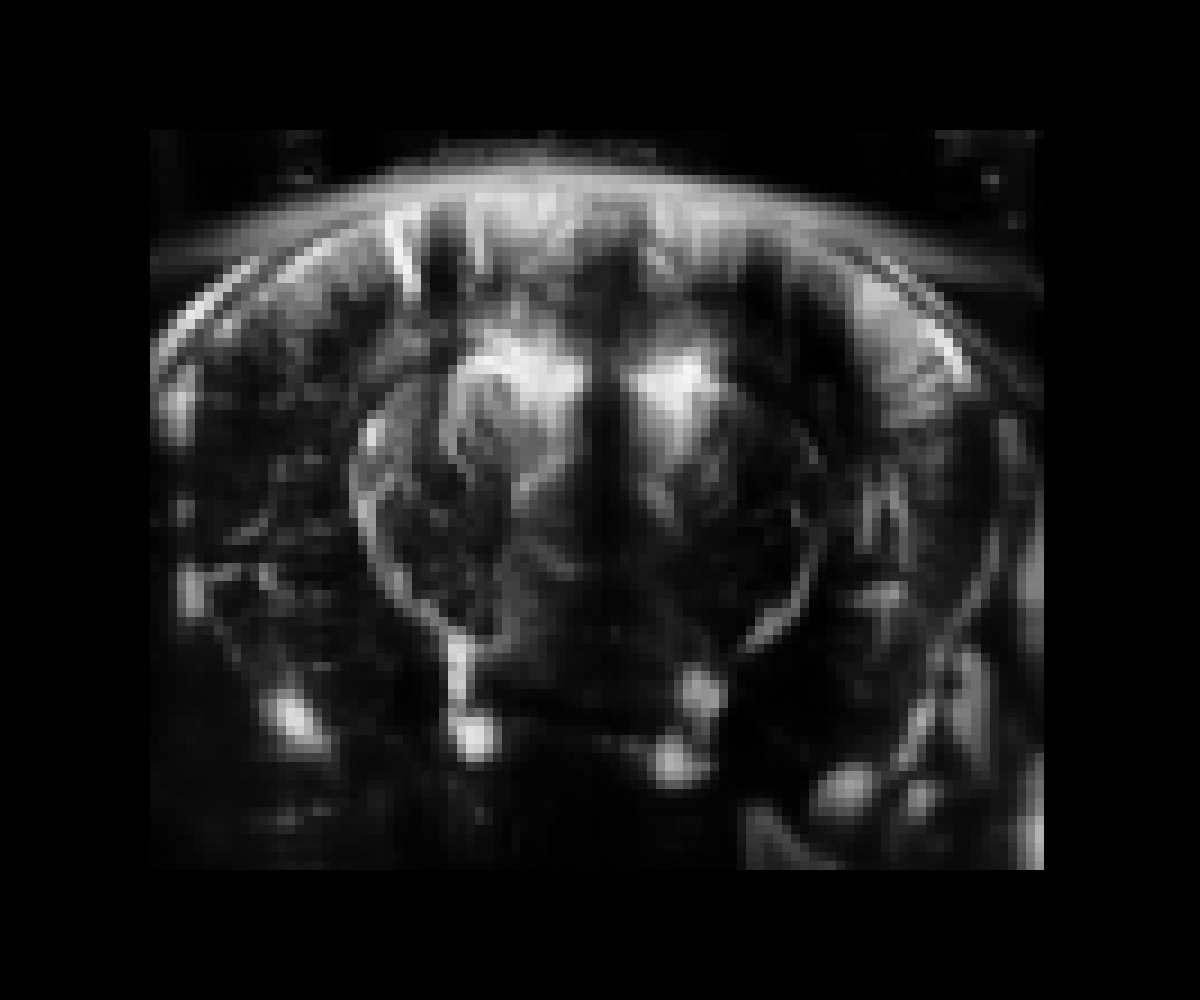

In [162]:
cropped_img

In [ ]:
for file_name in tqdm(root_3D_dir):

    prefix = file_name.name.split('acq')[0]

'sub-cp230405a_ses-1MEDISOses2_acq-3Dscan_probe-linear_'

In [42]:

for x in img_list:

    print(x.name)

sub-cp230405a_ses-1MEDISOses2_task-rest_acq-3Dfus_probe-linear_pose-0_sliceComparison.png
sub-cp230405a_ses-1MEDISOses2_task-rest_acq-3Dfus_probe-linear_pose-1_sliceComparison.png
sub-cp230405a_ses-1MEDISOses2_task-rest_acq-3Dfus_probe-linear_pose-2_sliceComparison.png
sub-cp230405a_ses-1MEDISOses2_task-rest_acq-3Dfus_probe-linear_pose-3_sliceComparison.png


In [24]:
img_name = [x for x in save_dir_QC.rglob('*') if x.is_file() and re.match(f'^.*{prefix}.*coronal.*.png$', x.name)][0]
print(img_name)

/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/77_QCs/00_individual_checks/sub-cp230405a/ses-1MEDISOses2/sub-cp230405a_ses-1MEDISOses2_acq-3Dscan_probe-linear_coronal.png


In [15]:
prefix

'sub-cp230405a_ses-1MEDISOses2_acq-3Dscan_probe-linear_'

In [ ]:
file_dir = sorted([])

In [ ]:
for file_name in tqdm(root_dir):

    file_title = ' - '.join(file_name.name.split('_task')[0].split('_'))
    
    # set background
    
    c.setFillColorRGB(0,0,0)
    c.rect(0,0,w,h,fill=1)
    
    # title
    
    c.setFillColorRGB(1,1,1)
    c.setFont("Montserrat-Light", 15)
    c.drawString(10, h-20, file_title)
    
    imgs = [file_name]
    
    for i, img_path in enumerate(imgs):
    
        img = ImageReader(img_path)
        img_w, img_h = img.getSize()
    
        c.drawImage(img, 0.05*w + (0.9*R[:i].sum()*w), 30, width=0.9*w*R[i], height = img_h*(0.9*w*R[i])/(img_w))
    
    c.showPage()

c.save()    
    

In [5]:
os.getcwd()

'/home/jmariani/Documents/python/fUS-analysis/standardized/re-analysis_Pepe-Mariani'

# End